# Homework 3.3

## Setup

In [1]:
import math
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets
from torchvision.transforms import v2

from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

Device: cuda


## Hyperparameters

In [24]:
num_epochs = 10
batch_size = 512
width = 128
temperature = 0.1
num_workers = 2

contrastive_augmentation   = {'min_area': 0.25, 'brightness': 0.6, 'jitter': 0.2}
classification_augmentation = {'min_area': 0.75, 'brightness': 0.3, 'jitter': 0.1}

## Augmentations



In [25]:
to_image = v2.ToImage()

def get_augmenter(min_area, brightness, jitter):
    return v2.Compose([
        v2.ToDtype(torch.float32, scale=True),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomResizedCrop(size=(96, 96), scale=(min_area, 1.0), antialias=True),
        v2.ColorJitter(brightness=brightness, contrast=jitter, saturation=jitter, hue=min(0.5, jitter)),
    ])

def get_eval_transform():
    return v2.Compose([v2.ToDtype(torch.float32, scale=True)])

contrastive_transform    = get_augmenter(**contrastive_augmentation)
classification_transform = get_augmenter(**classification_augmentation)
eval_transform           = get_eval_transform()

## Models

In [26]:
class Encoder(nn.Module):
    def __init__(self, width=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32,  kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv2d(64, 128,kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv2d(128,128,kernel_size=3, stride=2), nn.ReLU(),
        )
        self.flatten = nn.Flatten()
        self.fc = nn.LazyLinear(width)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = F.relu(self.fc(x))
        return x

def get_encoder():
    return Encoder(width=width)


class ContrastiveModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = get_encoder()
        self.projection_head = nn.Sequential(
            nn.Linear(width, width), nn.ReLU(), nn.Linear(width, width)
        )
        self.linear_probe = nn.Linear(width, 10)

    def encode_project(self, x):
        feats = self.encoder(x)
        proj  = self.projection_head(feats)
        return feats, proj


class FinetuneClassifier(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(width, 10)

    def forward(self, x):
        return self.head(self.encoder(x))

## Training functions

In [27]:
def contrastive_loss_and_acc(z1, z2, temperature=0.1):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    logits = z1 @ z2.T / temperature
    labels = torch.arange(z1.size(0), device=z1.device)
    loss = 0.5 * (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels))
    acc  = 0.5 * ((logits.argmax(dim=1) == labels).float().mean() +
                  (logits.T.argmax(dim=1) == labels).float().mean())
    return loss, acc


@torch.no_grad()
def evaluate_classifier(model, loader, eval_tf):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y   = x.to(device), y.to(device)
        logits = model(eval_tf(x))
        loss_sum += F.cross_entropy(logits, y).item() * y.size(0)
        correct  += (logits.argmax(1) == y).sum().item()
        total    += y.size(0)
    return loss_sum / total, correct / total


def train_supervised(model, train_loader, val_loader, train_tf, eval_tf, epochs=20, lr=1e-3):
    model = model.to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    hist  = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

    for ep in range(1, epochs + 1):
        model.train()
        tr_loss, tr_total, tr_correct = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(train_tf(x))
            loss   = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()
            tr_loss    += loss.item() * y.size(0)
            tr_total   += y.size(0)
            tr_correct += (logits.argmax(1) == y).sum().item()

        va_loss, va_acc = evaluate_classifier(model, val_loader, eval_tf)
        hist['loss'].append(tr_loss / tr_total)
        hist['acc'].append(tr_correct / tr_total)
        hist['val_loss'].append(va_loss)
        hist['val_acc'].append(va_acc)
        print(f'Epoch {ep:02d}/{epochs}  loss {tr_loss/tr_total:.4f}  val_acc {va_acc:.4f}')

    return model, hist


def train_contrastive(model, unl_loader, lbl_loader, val_loader, epochs=20, lr=1e-3):
    model = model.to(device)
    contrastive_opt = torch.optim.Adam(
        list(model.encoder.parameters()) + list(model.projection_head.parameters()), lr=lr)
    probe_opt = torch.optim.Adam(model.linear_probe.parameters(), lr=lr)

    hist = {'c_loss': [], 'c_acc': [], 'p_loss': [], 'p_acc': [], 'val_p_loss': [], 'val_p_acc': []}

    for ep in range(1, epochs + 1):
        model.train()
        c_loss_sum = c_acc_sum = p_loss_sum = p_acc_sum = steps = 0

        for (u_x, _), (l_x, l_y) in zip(unl_loader, lbl_loader):
            u_x, l_x, l_y = u_x.to(device), l_x.to(device), l_y.to(device)
            imgs = torch.cat([u_x, l_x], dim=0)

            contrastive_opt.zero_grad(set_to_none=True)
            _, z1 = model.encode_project(contrastive_transform(imgs))
            _, z2 = model.encode_project(contrastive_transform(imgs))
            c_loss, c_acc = contrastive_loss_and_acc(z1, z2, temperature)
            c_loss.backward()
            contrastive_opt.step()

            probe_opt.zero_grad(set_to_none=True)
            with torch.no_grad():
                f_probe = model.encoder(classification_transform(l_x))
            p_logits = model.linear_probe(f_probe)
            p_loss   = F.cross_entropy(p_logits, l_y)
            p_loss.backward()
            probe_opt.step()

            c_loss_sum += c_loss.item(); c_acc_sum += c_acc.item()
            p_loss_sum += p_loss.item()
            p_acc_sum  += (p_logits.argmax(1) == l_y).float().mean().item()
            steps += 1

        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model.linear_probe(model.encoder(eval_transform(x)))
                vl += F.cross_entropy(logits, y).item() * y.size(0)
                vc += (logits.argmax(1) == y).sum().item()
                vt += y.size(0)

        hist['c_loss'].append(c_loss_sum / steps); hist['c_acc'].append(c_acc_sum / steps)
        hist['p_loss'].append(p_loss_sum / steps); hist['p_acc'].append(p_acc_sum / steps)
        hist['val_p_loss'].append(vl / vt);        hist['val_p_acc'].append(vc / vt)

        print(f'Epoch {ep:02d}/{epochs}  c_loss {c_loss_sum/steps:.4f}  '
              f'c_acc {c_acc_sum/steps:.4f}  val_p_acc {vc/vt:.4f}')

    return model, hist

---
# Task 3.3.1

## Baseline — random encoder trained on labeled data only

In [28]:
full_unlabeled   = datasets.STL10(root='./data', split='unlabeled', download=True, transform=to_image)
labeled_dataset  = datasets.STL10(root='./data', split='train',     download=True, transform=to_image)
test_dataset     = datasets.STL10(root='./data', split='test',      download=True, transform=to_image)

labeled_loader = DataLoader(labeled_dataset, batch_size=batch_size,
                            shuffle=True,  num_workers=num_workers, pin_memory=True, drop_last=True)
test_loader    = DataLoader(test_dataset,   batch_size=batch_size,
                            shuffle=False, num_workers=num_workers, pin_memory=True)

print('Training baseline ...')

class BaselineClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = get_encoder()
        self.head    = nn.Linear(width, 10)
    def forward(self, x):
        return self.head(self.encoder(x))

seed_everything(42)
baseline_model, baseline_hist = train_supervised(
    BaselineClassifier(), labeled_loader, test_loader,
    train_tf=classification_transform, eval_tf=eval_transform, epochs=num_epochs)

print(f'\nBaseline best val acc: {max(baseline_hist["val_acc"])*100:.2f}%')

Training baseline ...
Epoch 01/10  loss 2.2824  val_acc 0.1951
Epoch 02/10  loss 2.1404  val_acc 0.2659
Epoch 03/10  loss 2.1269  val_acc 0.2261
Epoch 04/10  loss 2.0250  val_acc 0.2935
Epoch 05/10  loss 1.9082  val_acc 0.2994
Epoch 06/10  loss 1.8633  val_acc 0.3536
Epoch 07/10  loss 1.7796  val_acc 0.3564
Epoch 08/10  loss 1.7770  val_acc 0.3799
Epoch 09/10  loss 1.7224  val_acc 0.3850
Epoch 10/10  loss 1.6871  val_acc 0.3789

Baseline best val acc: 38.50%


## SimCLR — pretrain on 10%, 20%, 30%, 40% unlabeled, then fine-tune

In [29]:
fractions = [0.10, 0.20, 0.30, 0.40]

all_finetune_hists  = {}
all_pretrain_hists  = {}
saved_encoders      = {}

for frac in fractions:
    n_unlabeled = int(len(full_unlabeled) * frac)
    pct = int(frac * 100)
    print(f'\n====  {pct}% unlabeled  ({n_unlabeled} images)  ====')

    indices          = np.random.default_rng(42).choice(len(full_unlabeled), n_unlabeled, replace=False)
    unlabeled_subset = Subset(full_unlabeled, indices.tolist())

    steps_per_epoch      = (n_unlabeled + len(labeled_dataset)) // batch_size
    unlabeled_batch_size = n_unlabeled            // steps_per_epoch
    labeled_batch_size   = len(labeled_dataset)   // steps_per_epoch

    unl_loader = DataLoader(unlabeled_subset, batch_size=unlabeled_batch_size,
                            shuffle=True,  num_workers=num_workers, pin_memory=True, drop_last=True)
    lbl_loader = DataLoader(labeled_dataset,  batch_size=labeled_batch_size,
                            shuffle=True,  num_workers=num_workers, pin_memory=True, drop_last=True)

    seed_everything(42)
    contrastive_model = ContrastiveModel()
    contrastive_model, pretrain_hist = train_contrastive(
        contrastive_model, unl_loader, lbl_loader, test_loader, epochs=num_epochs)

    print('Fine-tuning ...')
    finetune_model = FinetuneClassifier(contrastive_model.encoder)
    finetune_model, finetune_hist = train_supervised(
        finetune_model, lbl_loader, test_loader,
        train_tf=classification_transform, eval_tf=eval_transform, epochs=num_epochs)

    all_pretrain_hists[pct] = pretrain_hist
    all_finetune_hists[pct] = finetune_hist
    saved_encoders[pct]     = contrastive_model.encoder

    print(f'[{pct}%] best fine-tune val acc: {max(finetune_hist["val_acc"])*100:.2f}%')


====  10% unlabeled  (10000 images)  ====
Epoch 01/10  c_loss 6.2340  c_acc 0.0126  val_p_acc 0.1098
Epoch 02/10  c_loss 5.7651  c_acc 0.0439  val_p_acc 0.1116
Epoch 03/10  c_loss 5.4934  c_acc 0.0860  val_p_acc 0.1878
Epoch 04/10  c_loss 5.1691  c_acc 0.0779  val_p_acc 0.1817
Epoch 05/10  c_loss 5.0205  c_acc 0.0924  val_p_acc 0.1945
Epoch 06/10  c_loss 5.0011  c_acc 0.1298  val_p_acc 0.2300
Epoch 07/10  c_loss 5.0969  c_acc 0.1183  val_p_acc 0.2405
Epoch 08/10  c_loss 4.6377  c_acc 0.1603  val_p_acc 0.2484
Epoch 09/10  c_loss 4.6167  c_acc 0.1474  val_p_acc 0.2676
Epoch 10/10  c_loss 4.7264  c_acc 0.1082  val_p_acc 0.2515
Fine-tuning ...
Epoch 01/10  loss 2.1934  val_acc 0.2675
Epoch 02/10  loss 1.9173  val_acc 0.3451
Epoch 03/10  loss 1.7489  val_acc 0.3911
Epoch 04/10  loss 1.6626  val_acc 0.3972
Epoch 05/10  loss 1.6370  val_acc 0.4051
Epoch 06/10  loss 1.5831  val_acc 0.4311
Epoch 07/10  loss 1.5443  val_acc 0.4542
Epoch 08/10  loss 1.5172  val_acc 0.4299
Epoch 09/10  loss 1.479

## Results table

In [30]:
print(f'{'Model':<25} {'Contr. Loss':>12} {'Contr. Acc':>12} {'Class. Loss':>12} {'Class. Acc':>12}')
print('-' * 75)

print(f'{'Baseline (no pretrain)':<25} {'N/A':>12} {'N/A':>12} '
      f'{baseline_hist["val_loss"][-1]:>12.4f} {max(baseline_hist["val_acc"]):>11.2%}')

for pct in [10, 20, 30, 40]:
    ph = all_pretrain_hists[pct]
    fh = all_finetune_hists[pct]
    print(f'{f"SimCLR {pct}% unlabeled":<25} '
          f'{ph["c_loss"][-1]:>12.4f} {ph["c_acc"][-1]:>11.2%} '
          f'{fh["val_loss"][-1]:>12.4f} {max(fh["val_acc"]):>11.2%}')

Model                      Contr. Loss   Contr. Acc  Class. Loss   Class. Acc
---------------------------------------------------------------------------
Baseline (no pretrain)             N/A          N/A       1.6541      38.50%
SimCLR 10% unlabeled            4.7264      10.82%       1.4467      45.42%
SimCLR 20% unlabeled            4.9839      13.70%       1.4205      47.16%
SimCLR 30% unlabeled            3.5621      29.13%       1.3345      52.36%
SimCLR 40% unlabeled            2.9518      41.99%       1.2587      54.45%


## Plot: validation accuracy over epochs for all models

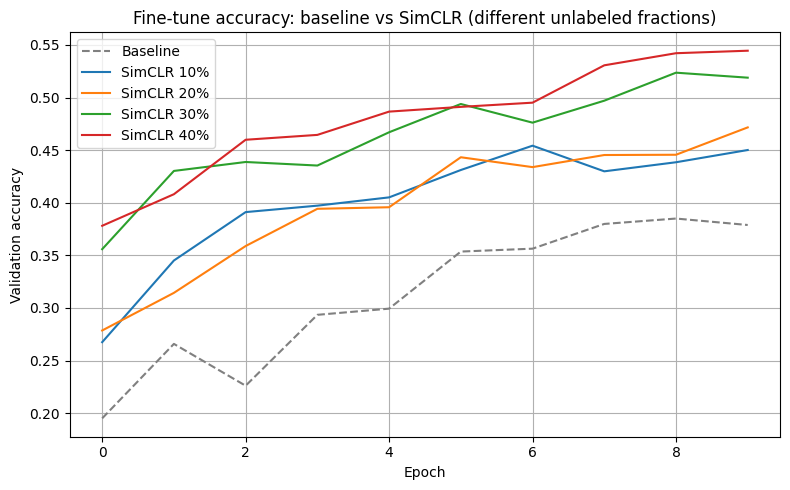

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(baseline_hist['val_acc'], label='Baseline', linestyle='--', color='gray')

for pct in [10, 20, 30, 40]:
    plt.plot(all_finetune_hists[pct]['val_acc'], label=f'SimCLR {pct}%')

plt.xlabel('Epoch')
plt.ylabel('Validation accuracy')
plt.title('Fine-tune accuracy: baseline vs SimCLR (different unlabeled fractions)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Task 3.3.2 — t-SNE Visualisation

We pick the **40% SimCLR model** and compare it to the baseline encoder.

In [32]:
@torch.no_grad()
def get_representations(encoder, loader):
    encoder.eval().to(device)
    all_feats, all_labels = [], []
    for x, y in loader:
        feats = encoder(eval_transform(x.to(device)))
        all_feats.append(feats.cpu().numpy())
        all_labels.append(y.numpy())
    return np.concatenate(all_feats), np.concatenate(all_labels)

vis_loader = DataLoader(labeled_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

feats_baseline, labels = get_representations(baseline_model.encoder, vis_loader)

feats_simclr, _ = get_representations(saved_encoders[40], vis_loader)

Extracting baseline representations...
Extracting SimCLR 40% representations...


In [33]:
tsne = TSNE(n_components=2, random_state=42)
baseline_2d = tsne.fit_transform(feats_baseline)
tsne = TSNE(n_components=2, random_state=42)
simclr_2d = tsne.fit_transform(feats_simclr)

Running t-SNE on baseline...
Running t-SNE on SimCLR...


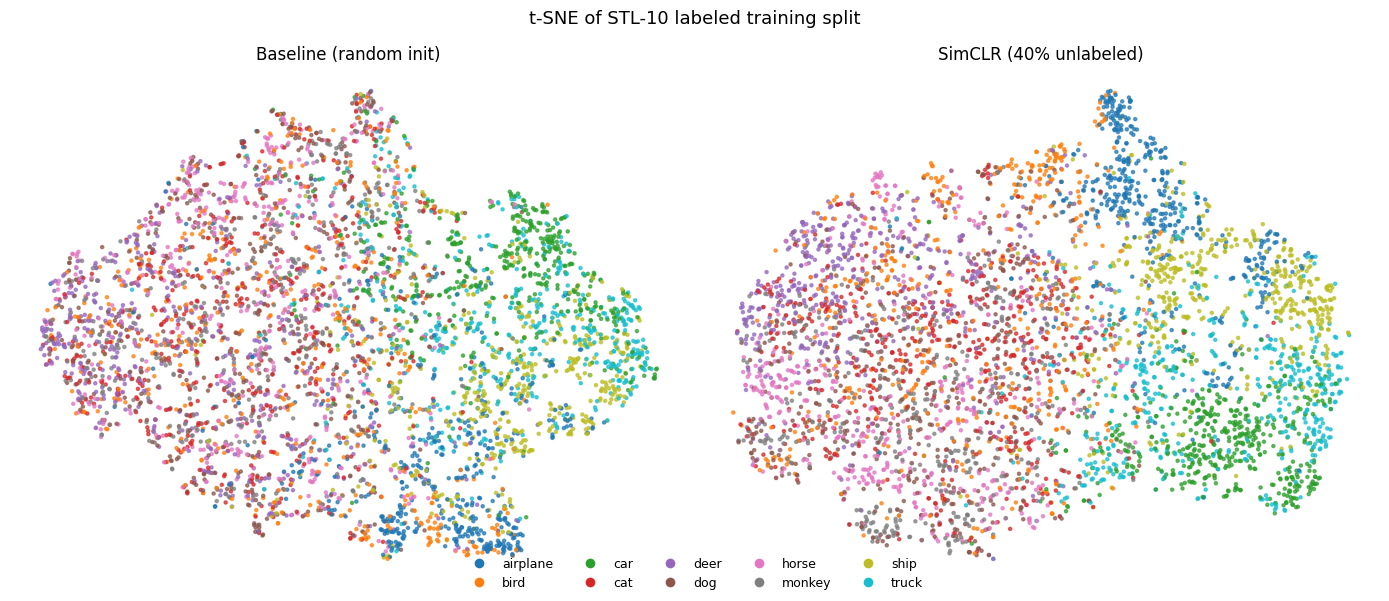

In [34]:
CLASS_NAMES = ['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, title in [
    (ax1, baseline_2d, 'Baseline (random init)'),
    (ax2, simclr_2d,   'SimCLR (40% unlabeled)'),
]:
    sc = ax.scatter(data[:, 0], data[:, 1], c=labels, cmap='tab10', s=5, alpha=0.7)
    ax.set_title(title)
    ax.axis('off')

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=plt.cm.tab10(i/10), markersize=8, label=CLASS_NAMES[i])
           for i in range(10)]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=9, frameon=False)

plt.suptitle('t-SNE of STL-10 labeled training split', fontsize=13)
plt.tight_layout()
plt.show()